In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split

In [2]:
#loading TCGA.BRCA(Breast canccer data)
expr = pd.read_csv("TCGA.BRCA.sampleMap_HiSeqV2", sep="\t")

In [3]:
print(expr.shape)

(20530, 1219)


In [4]:
expr = expr.set_index("sample")
x = expr.T  

In [5]:
x.shape

(1218, 20530)

In [6]:
clinical = pd.read_csv("TCGA.BRCA.sampleMap_BRCA_clinicalMatrix", sep="\t")


In [7]:
clinical.shape

(1247, 194)

In [8]:
print("PAM50Call_RNAseq" in clinical.columns)

True


In [9]:
clinical["PAM50Call_RNAseq"].value_counts()

PAM50Call_RNAseq
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64

In [10]:
print(clinical["sampleID"].head(10).tolist())

['TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01', 'TCGA-3C-AALJ-01', 'TCGA-3C-AALK-01', 'TCGA-4H-AAAK-01', 'TCGA-5L-AAT0-01', 'TCGA-5L-AAT1-01', 'TCGA-5T-A9QA-01', 'TCGA-A1-A0SB-01', 'TCGA-A1-A0SD-01']


In [11]:

clinical2 = clinical.set_index("sampleID")

y = clinical2.loc[x.index, "PAM50Call_RNAseq"]

In [12]:
print(y.head())
print(y.shape)

TCGA-AR-A5QQ-01     NaN
TCGA-D8-A1JA-01    Her2
TCGA-BH-A0BQ-01    LumA
TCGA-BH-A0BT-01    LumA
TCGA-A8-A06X-01    LumB
Name: PAM50Call_RNAseq, dtype: str
(1218,)


In [13]:
valid = y.notna()
x = x.loc[valid]
y = y.loc[valid]

In [14]:
print(type(x))
print(type(y))


<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [15]:
print("x:", x.shape)
print("y:", y.shape)

x: (956, 20530)
y: (956,)


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [17]:
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)

print("Y_train:", y_train.shape)
print("Y_test:", y_test.shape)


X_train: (764, 20530)
X_test: (192, 20530)
Y_train: (764,)
Y_test: (192,)


In [18]:
#ceating logistic regression model

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [19]:
#prdicting the test set
y_pred = model.predict(x_test)

In [20]:
#calculating accuracy

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("ACCURACY:", acc)

ACCURACY: 0.9166666666666666


In [21]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Basal       0.97      1.00      0.98        29
        Her2       0.91      0.77      0.83        13
        LumA       0.89      0.97      0.93        87
        LumB       0.88      0.77      0.82        39
      Normal       1.00      0.96      0.98        24

    accuracy                           0.92       192
   macro avg       0.93      0.89      0.91       192
weighted avg       0.92      0.92      0.91       192



In [23]:
#creating matrix heatmap
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[29  0  0  0  0]
 [ 0 10  2  1  0]
 [ 0  0 84  3  0]
 [ 1  1  7 30  0]
 [ 0  0  1  0 23]]


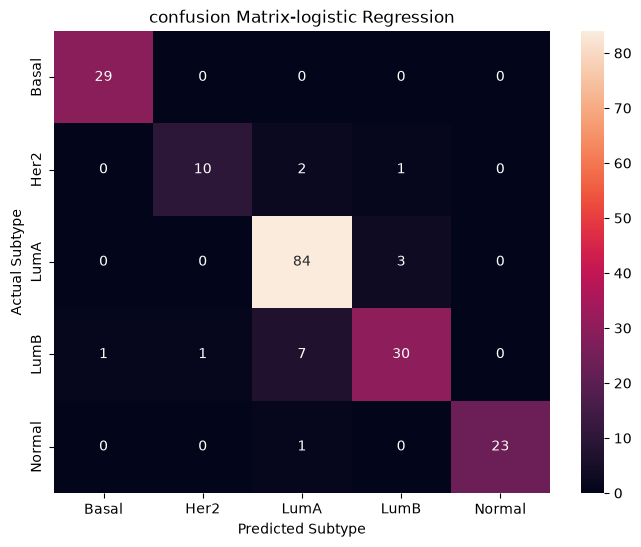

In [24]:
#heatmap for logistic regression
import seaborn as sns
import matplotlib.pyplot as plt
labels = model.classes_
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Subtype")
plt.ylabel("Actual Subtype")
plt.title("confusion Matrix-logistic Regression")
plt.savefig("confusion Matrix-logistic Regression", dpi=300, bbox_inches="tight")

In [25]:
#RandomForest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [26]:
y_pred_rf = rf_model.predict(x_test)

#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00        29
        Her2       0.89      0.62      0.73        13
        LumA       0.86      0.98      0.91        87
        LumB       0.80      0.72      0.76        39
      Normal       1.00      0.83      0.91        24

    accuracy                           0.89       192
   macro avg       0.91      0.83      0.86       192
weighted avg       0.89      0.89      0.88       192



In [28]:
#Cross validation(CV)
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf_model, x, y, cv=5)
print("CV Score:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

CV Score: [0.84895833 0.84293194 0.87958115 0.88481675 0.89005236]
Mean CV Score: 0.8692681064572426


In [29]:
# comparing logistic Regression and Random Forest Accuracy

from sklearn.metrics import accuracy_score
logistic_accuracy = accuracy_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Logistics Regression Accuracy:", logistic_accuracy)
print("Random forest Accuracy:", rf_accuracy)

Logistics Regression Accuracy: 0.9166666666666666
Random forest Accuracy: 0.8854166666666666


In [30]:
importances = rf_model.feature_importances_
print(importances.shape)

(20530,)


In [31]:
# Getting top 20 from the importance

import numpy as np
indices = np.argsort(importances)[-20:]
top_genes = x.columns[indices]
top_importances = importances[indices]
print(top_genes)

Index(['KCNJ11', 'FAM54A', 'CENPA', 'DLGAP5', 'ACADSB', 'MRAS', 'ESPL1',
       'SFRP1', 'DEGS2', 'FOXC1', 'TTK', 'TPX2', 'CCNA2', 'TRIM29', 'VGLL1',
       'UBE2T', 'STAC', 'ASPM', 'ROPN1B', 'TBC1D9'],
      dtype='str', name='sample')


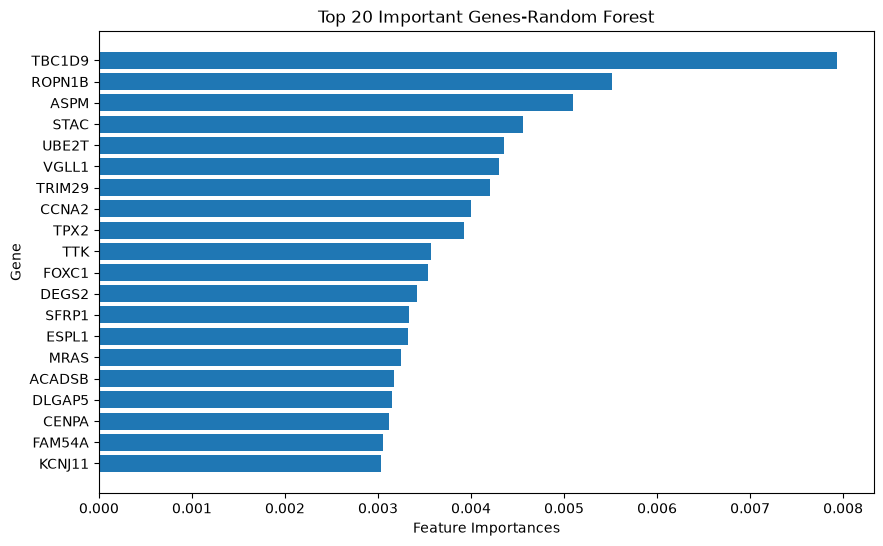

In [32]:
#top20 plot

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_genes, top_importances)
plt.xlabel("Feature Importances")
plt.ylabel("Gene")
plt.title("Top 20 Important Genes-Random Forest")
plt.savefig("Top 20 Important Genes-Random Forest", dpi=300, bbox_inches="tight")

In [33]:
#Model Evaluation(ROC{Receiver operating characteristics}-AUC{Area Under the Curve)

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

In [34]:
y_score = rf_model.predict_proba(x_test)

classes = rf_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_test_bin.shape

(192, 5)

In [35]:
#Calculating ROC&AUC for each subtype

for i, class_name in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
    print(f"{class_name} AUC:{auc:.3f}")

Basal AUC:1.000
Her2 AUC:0.982
LumA AUC:0.979
LumB AUC:0.966
Normal AUC:0.997


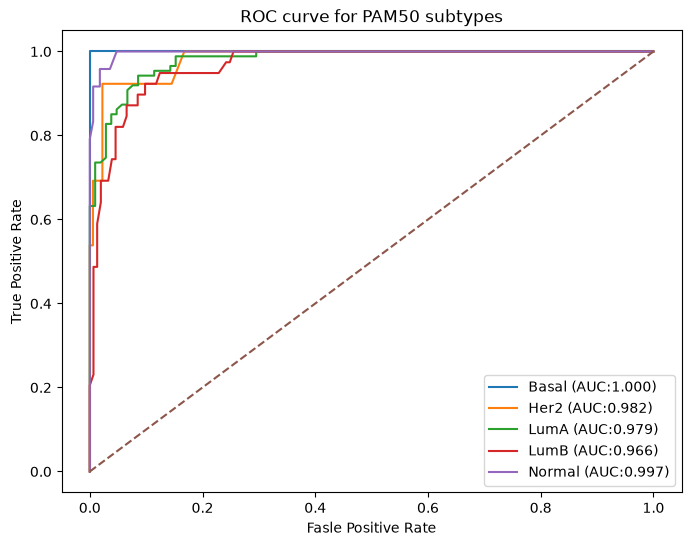

In [36]:
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
  fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
  auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
  plt.plot(fpr, tpr,label=f"{class_name} (AUC:{auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Fasle Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve for PAM50 subtypes")
plt.legend()
plt.savefig("ROC curve for PAM50 subtypes", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
#Calculating Macro-Average AUC

macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
print("Macro-Average AUC:", round(macro_auc, 3))

Macro-Average AUC: 0.985


When is AUC better than accuracy?

Accuracy measures the proportion of predictions that are correctly classified at one particular decision threshold. AUC measures how well the model distinguishes between classes across different thresholds. AUC can therefore be more informative when the classes are imbalanced or when the ability to discriminate between classes is more important than the final classification accuracy.